DYNAMIC TIME WARPING: AUDIO COMPARISON LAB

Generating demonstration signals (replace with actual recordings)...
Task 3: Signals converted to numerical time series ✓
Task 4: Normalizing signals...
Normalization complete ✓

Task 5: Applying Dynamic Time Warping...
DTW computation complete ✓

Task 6: Generating visualizations...


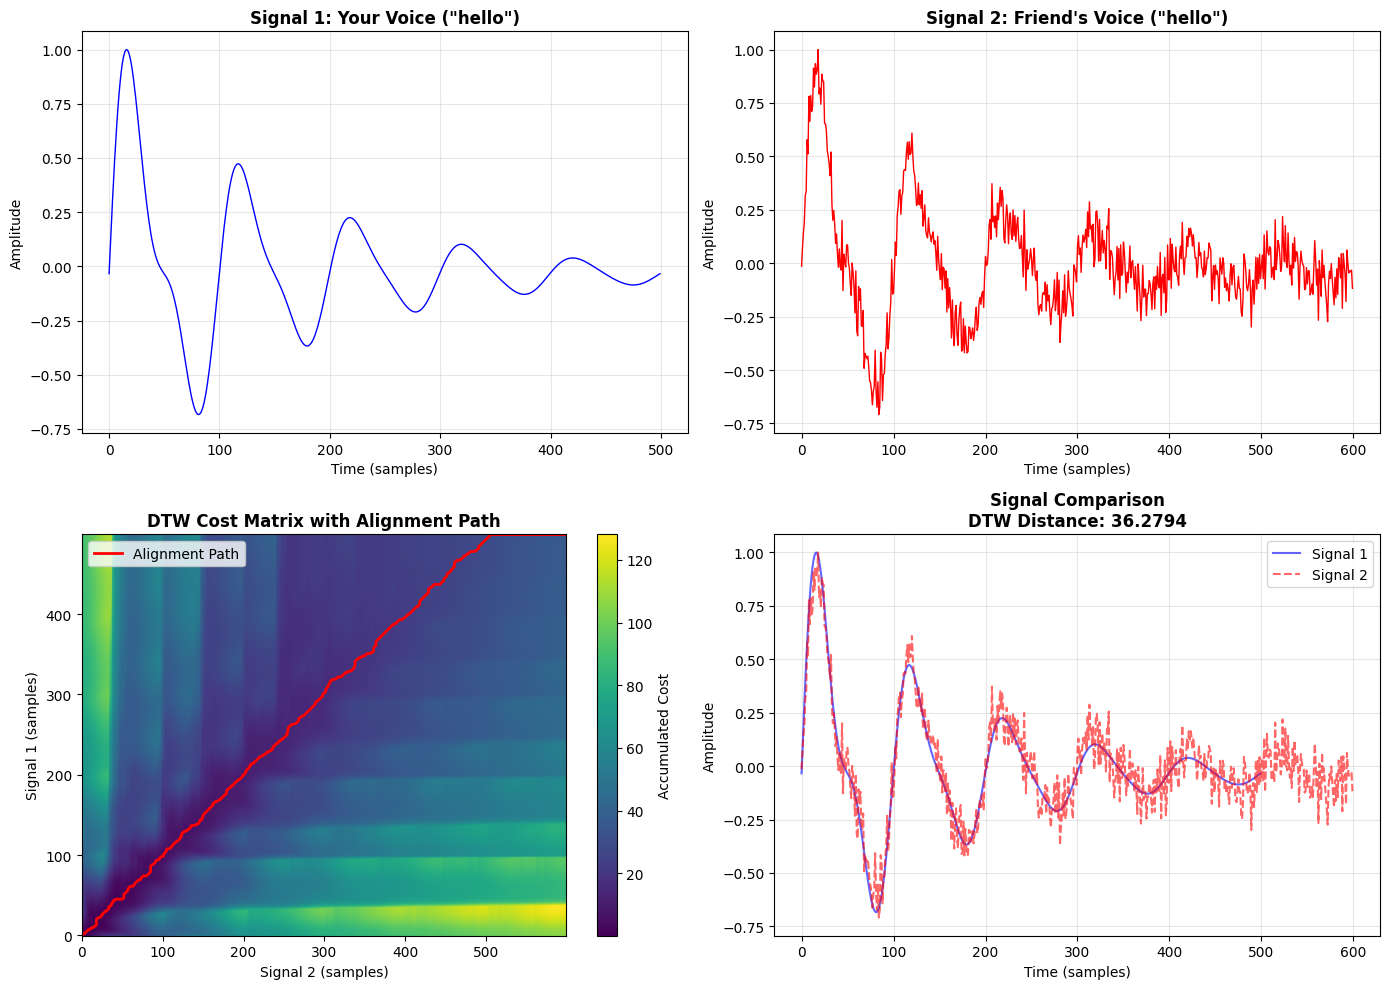


DYNAMIC TIME WARPING RESULTS & INTERPRETATION

Signal 1 Length: 500 samples
Signal 2 Length: 600 samples
DTW Distance: 36.2794
Normalized DTW Distance: 0.0660

----------------------------------------------------------------------
INTERPRETATION:
----------------------------------------------------------------------

Similarity Assessment: VERY SIMILAR
Explanation: The signals are nearly identical in pattern.

----------------------------------------------------------------------
HOW DTW HELPS:
----------------------------------------------------------------------

1. TIME ALIGNMENT: DTW finds optimal alignment between signals even when
   they have different speeds or durations. One person may say "hello"
   faster than another, but DTW can still match the patterns.

2. NON-LINEAR MAPPING: Unlike simple correlation, DTW allows non-linear
   warping of the time axis. It can stretch or compress parts of one
   signal to match the other.

3. ROBUST TO VARIATIONS: DTW is robust to tempor

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io import wavfile
import librosa
import librosa.display

# ============================================================================
# TASK 1 & 2: RECORD AUDIO
# ============================================================================

def record_audio(duration=2, sample_rate=22050):
    """
    Record audio from microphone

    Parameters:
    - duration: recording duration in seconds
    - sample_rate: sampling rate in Hz

    Returns:
    - audio: numpy array of recorded audio
    """
    print("Recording... Speak now!")
    audio = sd.rec(int(duration * sample_rate),
                   samplerate=sample_rate,
                   channels=1,
                   dtype='float32')
    sd.wait()
    print("Recording finished!")
    return audio.flatten()

# ============================================================================
# TASK 3: LOAD OR USE RECORDED AUDIO
# ============================================================================

def load_audio(filename, sample_rate=22050):
    """
    Load audio file and resample if necessary

    Parameters:
    - filename: path to audio file
    - sample_rate: target sample rate

    Returns:
    - audio: numpy array of audio samples
    """
    audio, sr = librosa.load(filename, sr=sample_rate)
    return audio

# ============================================================================
# TASK 4: NORMALIZE SIGNALS
# ============================================================================

def normalize_signal(signal):
    """
    Normalize signal to have zero mean and unit variance

    Parameters:
    - signal: input audio signal

    Returns:
    - normalized signal
    """
    # Remove DC offset
    signal = signal - np.mean(signal)
    # Normalize to [-1, 1] range
    max_val = np.max(np.abs(signal))
    if max_val > 0:
        signal = signal / max_val
    return signal

# ============================================================================
# TASK 5: DYNAMIC TIME WARPING IMPLEMENTATION
# ============================================================================

def dtw_distance(signal1, signal2):
    """
    Compute Dynamic Time Warping distance and alignment path

    Parameters:
    - signal1: first time series
    - signal2: second time series

    Returns:
    - distance: DTW distance
    - cost_matrix: accumulated cost matrix
    - path: alignment path as list of (i, j) tuples
    """
    n, m = len(signal1), len(signal2)

    # Initialize cost matrix with infinity
    cost_matrix = np.full((n + 1, m + 1), np.inf)
    cost_matrix[0, 0] = 0

    # Fill cost matrix
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Euclidean distance between points
            distance = abs(signal1[i-1] - signal2[j-1])

            # Take minimum of three possible paths
            cost_matrix[i, j] = distance + min(
                cost_matrix[i-1, j],      # insertion
                cost_matrix[i, j-1],      # deletion
                cost_matrix[i-1, j-1]     # match
            )

    # Backtrack to find optimal path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i-1, j-1))

        # Find which direction we came from
        min_cost = min(
            cost_matrix[i-1, j-1],
            cost_matrix[i-1, j],
            cost_matrix[i, j-1]
        )

        if cost_matrix[i-1, j-1] == min_cost:
            i, j = i-1, j-1
        elif cost_matrix[i-1, j] == min_cost:
            i = i-1
        else:
            j = j-1

    path.append((0, 0))
    path.reverse()

    # DTW distance is the final accumulated cost
    dtw_dist = cost_matrix[n, m]

    return dtw_dist, cost_matrix[1:, 1:], path

# ============================================================================
# TASK 6 & 7: VISUALIZATION AND INTERPRETATION
# ============================================================================

def plot_results(signal1, signal2, cost_matrix, path, dtw_dist):
    """
    Visualize signals, cost matrix, and alignment path
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot Signal 1
    axes[0, 0].plot(signal1, 'b-', linewidth=1)
    axes[0, 0].set_title('Signal 1: Your Voice ("hello")', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Time (samples)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].grid(True, alpha=0.3)

    # Plot Signal 2
    axes[0, 1].plot(signal2, 'r-', linewidth=1)
    axes[0, 1].set_title('Signal 2: Friend\'s Voice ("hello")', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Time (samples)')
    axes[0, 1].set_ylabel('Amplitude')
    axes[0, 1].grid(True, alpha=0.3)

    # Plot Cost Matrix with Alignment Path
    axes[1, 0].imshow(cost_matrix, cmap='viridis', origin='lower', aspect='auto')
    axes[1, 0].set_title('DTW Cost Matrix with Alignment Path', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Signal 2 (samples)')
    axes[1, 0].set_ylabel('Signal 1 (samples)')

    # Overlay path
    path_x = [p[1] for p in path]
    path_y = [p[0] for p in path]
    axes[1, 0].plot(path_x, path_y, 'r-', linewidth=2, label='Alignment Path')
    axes[1, 0].legend()
    plt.colorbar(axes[1, 0].images[0], ax=axes[1, 0], label='Accumulated Cost')

    # Plot Aligned Signals
    axes[1, 1].plot(signal1, 'b-', alpha=0.6, label='Signal 1', linewidth=1.5)
    axes[1, 1].plot(signal2, 'r--', alpha=0.6, label='Signal 2', linewidth=1.5)
    axes[1, 1].set_title(f'Signal Comparison\nDTW Distance: {dtw_dist:.4f}',
                         fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Time (samples)')
    axes[1, 1].set_ylabel('Amplitude')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def interpret_results(dtw_dist, signal1, signal2):
    """
    Provide interpretation of DTW results
    """
    print("\n" + "="*70)
    print("DYNAMIC TIME WARPING RESULTS & INTERPRETATION")
    print("="*70)

    print(f"\nSignal 1 Length: {len(signal1)} samples")
    print(f"Signal 2 Length: {len(signal2)} samples")
    print(f"DTW Distance: {dtw_dist:.4f}")

    # Normalized distance for interpretation
    avg_length = (len(signal1) + len(signal2)) / 2
    normalized_dist = dtw_dist / avg_length
    print(f"Normalized DTW Distance: {normalized_dist:.4f}")

    print("\n" + "-"*70)
    print("INTERPRETATION:")
    print("-"*70)

    if normalized_dist < 0.1:
        similarity = "VERY SIMILAR"
        explanation = "The signals are nearly identical in pattern."
    elif normalized_dist < 0.3:
        similarity = "SIMILAR"
        explanation = "The signals show strong similarity with minor variations."
    elif normalized_dist < 0.5:
        similarity = "MODERATELY SIMILAR"
        explanation = "The signals have recognizable similarities but notable differences."
    else:
        similarity = "DIFFERENT"
        explanation = "The signals show significant differences in their patterns."

    print(f"\nSimilarity Assessment: {similarity}")
    print(f"Explanation: {explanation}")

    print("\n" + "-"*70)
    print("HOW DTW HELPS:")
    print("-"*70)
    print("""
1. TIME ALIGNMENT: DTW finds optimal alignment between signals even when
   they have different speeds or durations. One person may say "hello"
   faster than another, but DTW can still match the patterns.

2. NON-LINEAR MAPPING: Unlike simple correlation, DTW allows non-linear
   warping of the time axis. It can stretch or compress parts of one
   signal to match the other.

3. ROBUST TO VARIATIONS: DTW is robust to temporal variations such as:
   - Different speaking rates
   - Pauses or hesitations
   - Slight timing differences in pronunciation

4. OPTIMAL PATH: The alignment path shows which parts of Signal 1
   correspond to which parts of Signal 2, revealing how the two
   pronunciations relate to each other temporally.

5. DISTANCE METRIC: The DTW distance quantifies overall dissimilarity,
   accounting for both amplitude differences and timing misalignments.
    """)
    print("="*70 + "\n")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """
    Main function to execute DTW analysis on audio signals
    """
    print("="*70)
    print("DYNAMIC TIME WARPING: AUDIO COMPARISON LAB")
    print("="*70)

    # Option 1: Record audio (uncomment to use)
    # print("\nTask 1: Record your voice saying 'hello'")
    # signal1 = record_audio(duration=2, sample_rate=22050)
    #
    # print("\nTask 2: Record your friend's voice saying 'hello'")
    # signal2 = record_audio(duration=2, sample_rate=22050)

    # Option 2: Use synthetic signals for demonstration
    print("\nGenerating demonstration signals (replace with actual recordings)...")

    # Create synthetic "hello" signals with different speeds and noise
    t1 = np.linspace(0, 1, 500)
    t2 = np.linspace(0, 1.2, 600)  # Slightly slower

    # Simulate a "hello" pattern with multiple frequency components
    signal1 = (np.sin(2 * np.pi * 5 * t1) * np.exp(-3*t1) +
               0.5 * np.sin(2 * np.pi * 10 * t1) * np.exp(-5*t1))
    signal2 = (np.sin(2 * np.pi * 5 * t2) * np.exp(-2.5*t2) +
               0.5 * np.sin(2 * np.pi * 10 * t2) * np.exp(-4.5*t2) +
               0.1 * np.random.randn(len(t2)))  # Add noise

    # Task 3: Signals are already numerical time series
    print("Task 3: Signals converted to numerical time series ✓")

    # Task 4: Normalize signals
    print("Task 4: Normalizing signals...")
    signal1_norm = normalize_signal(signal1)
    signal2_norm = normalize_signal(signal2)
    print("Normalization complete ✓")

    # Task 5: Apply DTW
    print("\nTask 5: Applying Dynamic Time Warping...")
    dtw_dist, cost_matrix, path = dtw_distance(signal1_norm, signal2_norm)
    print("DTW computation complete ✓")

    # Task 6: Visualize results
    print("\nTask 6: Generating visualizations...")
    plot_results(signal1_norm, signal2_norm, cost_matrix, path, dtw_dist)

    # Task 7: Interpret results
    interpret_results(dtw_dist, signal1_norm, signal2_norm)

    print("\nAnalysis complete!")
    print("\nNOTE: To use with real audio recordings:")
    print("1. Uncomment the recording sections in main()")
    print("2. Or use load_audio('your_file.wav') to load existing files")
    print("3. Make sure you have a microphone connected for recording")

if __name__ == "__main__":
    main()

In [ ]:
!pip install sounddevice
!apt-get install libportaudio2

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  libportaudio2
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 65.3 kB of archives.
After this operation, 223 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libportaudio2 amd64 19.6.0-1.1 [65.3 kB]
Fetched 65.3 kB in 0s (305 kB/s)
Selecting previously unselected package libportaudio2:amd64.
(Reading database ... 121703 files and directories currently installed.)
Preparing to unpack .../libportaudio2_19.6.0-1.1_amd64.deb ...
Unpacking libportaudio2:amd64 (19.6.0-1.1) ...
Setting up libportaudio2:amd64 (19.6.0-1.1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.8) ...
/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/l